In [73]:
# 数据初处理
import pandas as pd
import numpy as np

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns

# 忽略警告
import warnings
warnings.filterwarnings("ignore")

# 设置显示格式
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [74]:
# 数据路径
file_path = "heart_failure_clinical_records_dataset.csv"

# 读取数据
df = pd.read_csv(file_path)

# 查看前5行
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [75]:
# 行数和列数
df.shape

(299, 13)

In [76]:
#查看变量名称
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='str')

In [77]:
#查看数据类型
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [78]:
#描述性统计
print(df.describe().T)

                          count           mean           std      min  \
age                       299.0      60.833893     11.894809     40.0   
anaemia                   299.0       0.431438      0.496107      0.0   
creatinine_phosphokinase  299.0     581.839465    970.287881     23.0   
diabetes                  299.0       0.418060      0.494067      0.0   
ejection_fraction         299.0      38.083612     11.834841     14.0   
high_blood_pressure       299.0       0.351171      0.478136      0.0   
platelets                 299.0  263358.029264  97804.236869  25100.0   
serum_creatinine          299.0       1.393880      1.034510      0.5   
serum_sodium              299.0     136.625418      4.412477    113.0   
sex                       299.0       0.648829      0.478136      0.0   
smoking                   299.0       0.321070      0.467670      0.0   
time                      299.0     130.260870     77.614208      4.0   
DEATH_EVENT               299.0       0.321070     

In [79]:
#查看变量类型
categorical_cols = [
    'anaemia',
    'diabetes',
    'high_blood_pressure',
    'sex',
    'smoking',
    'DEATH_EVENT'
]


for col in categorical_cols:
    print("\n变量:", col)
    print(df[col].value_counts())


变量: anaemia
anaemia
0    170
1    129
Name: count, dtype: int64

变量: diabetes
diabetes
0    174
1    125
Name: count, dtype: int64

变量: high_blood_pressure
high_blood_pressure
0    194
1    105
Name: count, dtype: int64

变量: sex
sex
1    194
0    105
Name: count, dtype: int64

变量: smoking
smoking
0    203
1     96
Name: count, dtype: int64

变量: DEATH_EVENT
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


In [80]:
#查看缺失值
missing_values = df.isnull().sum()
missing_values

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [81]:
#异常值检测
numeric_cols = df.select_dtypes(
    include=['int64','float64']
).columns


outlier_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]


    outlier_summary.append({
        "Variable":col,
        "Lower Bound":lower,
        "Upper Bound":upper,
        "Outlier Count":len(outliers),
        "Outlier Percentage":len(outliers)/len(df)*100
    })


outlier_table = pd.DataFrame(outlier_summary)

outlier_table

,Variable,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,age,22.50,98.50,0,0.000000
1,anaemia,-1.50,2.50,0,0.000000
2,creatinine_phosphokinase,-581.75,1280.25,29,9.698997
3,diabetes,-1.50,2.50,0,0.000000
4,ejection_fraction,7.50,67.50,2,0.668896
5,high_blood_pressure,-1.50,2.50,0,0.000000
6,platelets,76000.00,440000.00,21,7.023411
7,serum_creatinine,0.15,2.15,29,9.698997
8,serum_sodium,125.00,149.00,4,1.337793
9,sex,-1.50,2.50,0,0.000000


In [82]:
#异常值处理
# 第一步：复制数据
df_processed = df.copy()
#
log_cols = [
    "creatinine_phosphokinase",
    "serum_creatinine"
]


for col in log_cols:

    df_processed[col] = np.log1p(
        df_processed[col]
    )

#缩尾处理
def winsorize_iqr(data, columns):
    """
    基于IQR进行缩尾处理
    """

    data = data.copy()

    for col in columns:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # 缩尾处理
        data[col] = np.where(
            data[col] < lower,
            lower,
            data[col]
        )

        data[col] = np.where(
            data[col] > upper,
            upper,
            data[col]
        )

    return data

winsor_cols = [
    "platelets",
    "serum_sodium",
    "ejection_fraction",
    "creatinine_phosphokinase",
    "serum_creatinine"
]


df_processed = winsorize_iqr(
    df_processed,
    winsor_cols
)


In [83]:
def detect_outliers(data, columns):

    result = []

    for col in columns:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3-Q1

        lower = Q1-1.5*IQR
        upper = Q3+1.5*IQR

        count = (
            (data[col]<lower) |
            (data[col]>upper)
        ).sum()

        result.append(
            {
                "Variable":col,
                "Outlier_Count":count
            }
        )

    return pd.DataFrame(result)



numeric_cols = df_processed.select_dtypes(
    include=["int64","float64"]
).columns


outlier_after = detect_outliers(
    df_processed,
    numeric_cols
)


outlier_after

,Variable,Outlier_Count
0,age,0
1,anaemia,0
2,creatinine_phosphokinase,0
3,diabetes,0
4,ejection_fraction,0
5,high_blood_pressure,0
6,platelets,0
7,serum_creatinine,0
8,serum_sodium,0
9,sex,0


In [84]:
#因子检测
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
#确定连续变量，去除目标变量
numeric_cols = df_processed.select_dtypes(
    include=['int64','float64']
).columns

features = numeric_cols.drop(
    'DEATH_EVENT'
)

#分离死亡组和存活组
# 存活组
survival_group = df_processed[
    df_processed['DEATH_EVENT']==0
]

# 死亡组
death_group = df_processed[
    df_processed['DEATH_EVENT']==1
]
#对每个指标进行T检验
t_test_results = []

for col in features:

    # 两组指标数据
    survival_data = survival_group[col]
    death_data = death_group[col]

    # 独立样本t检验
    t_stat, p_value = ttest_ind(
        survival_data,
        death_data,
        equal_var=False   # Welch t-test
    )

    # 均值差异
    mean_diff = (
        death_data.mean()
        -
        survival_data.mean()
    )


    t_test_results.append({
        'Feature': col,
        'Survival Mean': survival_data.mean(),
        'Death Mean': death_data.mean(),
        'Mean Difference': mean_diff,
        't-statistic': t_stat,
        'p-value': p_value,
        '|t-value|': abs(t_stat)
    })


t_test_results = pd.DataFrame(
    t_test_results
)
#按危险因子排序
risk_factor_rank = t_test_results.sort_values(
    by='|t-value|',
    ascending=False
)


risk_factor_rank

,Feature,Survival Mean,Death Mean,Mean Difference,t-statistic,p-value,|t-value|
11,time,158.339901,70.885417,-87.454485,11.006168,2.343276e-22,11.006168
7,serum_creatinine,0.740581,0.904472,0.163891,-6.576464,7.067334e-10,6.576464
4,ejection_fraction,40.204433,33.442708,-6.761725,4.584461,9.013976e-06,4.584461
0,age,58.761906,65.215281,6.453375,-4.186210,4.735215e-05,4.186210
8,serum_sodium,137.275862,135.520833,-1.755029,3.286170,1.254580e-03,3.286170
5,high_blood_pressure,0.325123,0.406250,0.081127,-1.347390,1.795643e-01,1.347390
1,anaemia,0.408867,0.479167,0.070300,-1.136898,2.570643e-01,1.136898
6,platelets,261632.366749,253943.544792,-7688.821957,0.723067,4.706656e-01,0.723067
2,creatinine_phosphokinase,5.640934,5.714406,0.073472,-0.525369,5.999532e-01,0.525369
10,smoking,0.325123,0.312500,-0.012623,0.218168,8.275348e-01,0.218168


In [85]:
#筛选显著危险因素
significant_factors = risk_factor_rank[
    risk_factor_rank['p-value'] < 0.05
]

significant_factors

,Feature,Survival Mean,Death Mean,Mean Difference,t-statistic,p-value,|t-value|
11,time,158.339901,70.885417,-87.454485,11.006168,2.343276e-22,11.006168
7,serum_creatinine,0.740581,0.904472,0.163891,-6.576464,7.067334e-10,6.576464
4,ejection_fraction,40.204433,33.442708,-6.761725,4.584461,9.013976e-06,4.584461
0,age,58.761906,65.215281,6.453375,-4.186210,4.735215e-05,4.186210
8,serum_sodium,137.275862,135.520833,-1.755029,3.286170,1.254580e-03,3.286170


In [86]:
#保存危险因子排序结果
risk_factor_rank.to_csv(
    "T_test_risk_factor_rank.csv",
    index=False
)

In [87]:
#画相关性热力图
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

#计算Spearman相关系数矩阵
# 计算Spearman相关矩阵

corr_matrix = df_processed.corr(
    method='spearman'
)

corr_matrix

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
age,1.000000,0.071924,-0.093095,-0.089657,0.074062,0.105740,-0.051029,0.271856,-0.101751,0.057791,0.030145,-0.197524,0.218125
anaemia,0.071924,1.000000,-0.216116,-0.012729,0.020405,0.038182,-0.035336,-0.017685,0.061484,-0.094769,-0.107290,-0.134652,0.066270
creatinine_phosphokinase,-0.093095,-0.216116,1.000000,0.042347,-0.067873,-0.080684,0.059739,-0.051515,0.016928,0.013298,-0.030351,0.125836,0.023616
diabetes,-0.089657,-0.012729,0.042347,1.000000,-0.011906,-0.012732,0.073401,0.002249,-0.055387,-0.157730,-0.147173,0.029501,-0.001943
ejection_fraction,0.074062,0.020405,-0.067873,-0.011906,1.000000,0.017984,0.053921,-0.179273,0.161554,-0.130792,-0.071748,0.070568,-0.286827
high_blood_pressure,0.105740,0.038182,-0.080684,-0.012732,0.017984,1.000000,0.068863,-0.090568,0.019200,-0.104615,-0.055711,-0.194794,0.079351
platelets,-0.051029,-0.035336,0.059739,0.073401,0.053921,0.068863,1.000000,-0.051514,0.048673,-0.136182,0.005313,-0.007556,-0.045787
serum_creatinine,0.271856,-0.017685,-0.051515,0.002249,-0.179273,-0.090568,-0.051514,1.000000,-0.300562,0.051584,-0.017010,-0.160739,0.370756
serum_sodium,-0.101751,0.061484,0.016928,-0.055387,0.161554,0.019200,0.048673,-0.300562,1.000000,-0.076921,0.008502,0.086316,-0.209837
sex,0.057791,-0.094769,0.013298,-0.157730,-0.130792,-0.104615,-0.136182,0.051584,-0.076921,1.000000,0.445892,-0.017332,-0.004316


In [88]:
#筛选指标
# 获取DEATH_EVENT相关系数

death_corr = corr_matrix[
    'DEATH_EVENT'
]


# 按相关系数绝对值排序
top10_features = (
    death_corr
    .abs()
    .sort_values(
        ascending=False
    )
    .head(11)
    .index
)


top10_features

Index(['DEATH_EVENT', 'time', 'serum_creatinine', 'ejection_fraction', 'age',
       'serum_sodium', 'high_blood_pressure', 'anaemia', 'platelets',
       'creatinine_phosphokinase', 'smoking'],
      dtype='str')

In [89]:
# 获取DEATH_EVENT相关系数

death_corr = corr_matrix[
    'DEATH_EVENT'
]


# 按相关系数绝对值排序
top10_features = (
    death_corr
    .abs()
    .sort_values(
        ascending=False
    )
    .head(11)
    .index
)

#去除目标函数+获取矩阵
top10_features = top10_features.drop(
    'DEATH_EVENT'
)
top10_corr = corr_matrix.loc[
    top10_features.tolist()+['DEATH_EVENT'],
    top10_features.tolist()+['DEATH_EVENT']
]


top10_corr

,time,serum_creatinine,ejection_fraction,age,serum_sodium,high_blood_pressure,anaemia,platelets,creatinine_phosphokinase,smoking,DEATH_EVENT
time,1.000000,-0.160739,0.070568,-0.197524,0.086316,-0.194794,-0.134652,-0.007556,0.125836,-0.026476,-0.543179
serum_creatinine,-0.160739,1.000000,-0.179273,0.271856,-0.300562,-0.090568,-0.017685,-0.051514,-0.051515,-0.017010,0.370756
ejection_fraction,0.070568,-0.179273,1.000000,0.074062,0.161554,0.017984,0.020405,0.053921,-0.067873,-0.071748,-0.286827
age,-0.197524,0.271856,0.074062,1.000000,-0.101751,0.105740,0.071924,-0.051029,-0.093095,0.030145,0.218125
serum_sodium,0.086316,-0.300562,0.161554,-0.101751,1.000000,0.019200,0.061484,0.048673,0.016928,0.008502,-0.209837
high_blood_pressure,-0.194794,-0.090568,0.017984,0.105740,0.019200,1.000000,0.038182,0.068863,-0.080684,-0.055711,0.079351
anaemia,-0.134652,-0.017685,0.020405,0.071924,0.061484,0.038182,1.000000,-0.035336,-0.216116,-0.107290,0.066270
platelets,-0.007556,-0.051514,0.053921,-0.051029,0.048673,0.068863,-0.035336,1.000000,0.059739,0.005313,-0.045787
creatinine_phosphokinase,0.125836,-0.051515,-0.067873,-0.093095,0.016928,-0.080684,-0.216116,0.059739,1.000000,-0.030351,0.023616
smoking,-0.026476,-0.017010,-0.071748,0.030145,0.008502,-0.055711,-0.107290,0.005313,-0.030351,1.000000,-0.012623


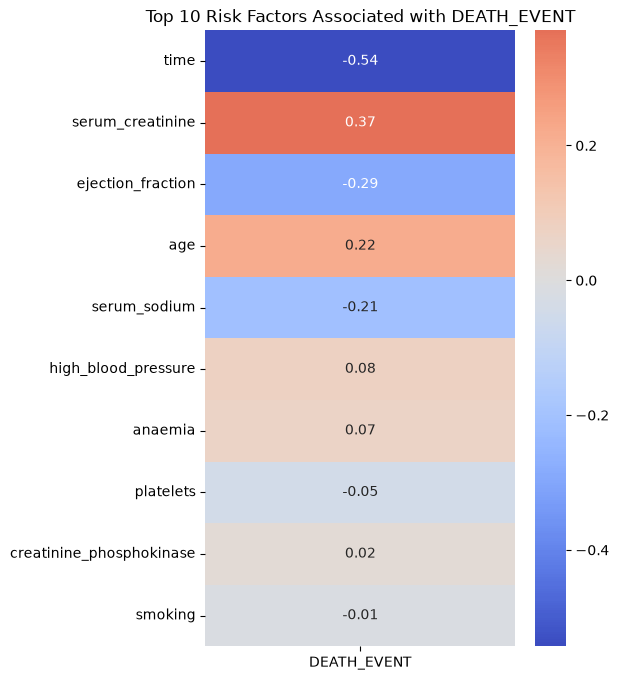

In [90]:
plt.figure(
    figsize=(5,8)
)


sns.heatmap(
    corr_matrix.loc[
        top10_features,
        ['DEATH_EVENT']
    ],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)


plt.title(
    "Top 10 Risk Factors Associated with DEATH_EVENT"
)


plt.show()

In [91]:
#3.建模
#导入库
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

#评价指标
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)


In [92]:
#构建训练数据
# 选择危险因素

features = [
    'time',
    'serum_creatinine',
    'ejection_fraction',
    'age',
    'serum_sodium'
]


X = df_processed[
    features
]


y = df_processed[
    'DEATH_EVENT'
]


X.head()

,time,serum_creatinine,ejection_fraction,age,serum_sodium
0,4,1.064711,20.0,75.0,130.0
1,6,0.741937,38.0,55.0,136.0
2,7,0.832909,20.0,65.0,129.0
3,7,1.064711,20.0,50.0,137.0
4,8,1.225891,20.0,65.0,125.0


In [93]:
#划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(
    "训练集:",
    X_train.shape
)

print(
    "测试集:",
    X_test.shape
)

训练集: (239, 5)
测试集: (60, 5)


In [94]:
#建立XGBoost模型
model = XGBClassifier(

    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,

    eval_metric='logloss'
)

model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


      Metric     Value
0   Accuracy  0.850000
1  Precision  0.857143
2     Recall  0.631579
3   F1-score  0.727273
AUC: 0.8741976893453145


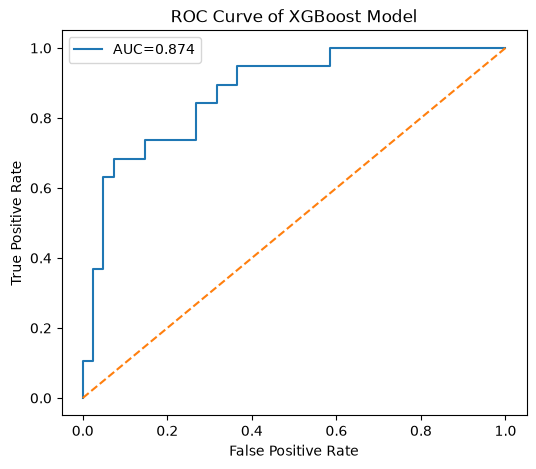

In [95]:
#模型评估
y_pred = model.predict(
    X_test
)
y_prob = model.predict_proba(
    X_test
)[:,1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

evaluation_result = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

print(evaluation_result)

#画图
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score
)


auc_score = roc_auc_score(
    y_test,
    y_prob
)


print(
    "AUC:",
    auc_score
)


import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)


plt.figure(figsize=(6,5))


plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc_score:.3f}"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve of XGBoost Model"
)


plt.legend()

plt.show()


In [96]:
#新患者示例
#输入
new_patient = pd.DataFrame({

    "time":[100],

    "serum_creatinine":[1.8],

    "ejection_fraction":[35],

    "age":[70],

    "serum_sodium":[135]

})
#输出
death_probability = model.predict_proba(
    new_patient
)[0,1]


print(
    "该患者随访期内死亡概率:",
    round(death_probability,3)
)

该患者随访期内死亡概率: 0.318


In [97]:
#Logistic Regression模型
#由于该模型对变量尺度敏感，需要标准化
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# 标准化
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# 建立模型
lr_model = LogisticRegression(
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)
lr_pred = lr_model.predict(
    X_test_scaled
)
lr_prob = lr_model.predict_proba(
    X_test_scaled
)[:,1]

In [98]:
#模型评价
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr_result = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Value":[
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred),
        roc_auc_score(y_test, lr_prob)
    ]

})

lr_result

,Metric,Value
0,Accuracy,0.833333
1,Precision,0.800000
2,Recall,0.631579
3,F1-score,0.705882
4,AUC,0.889602


In [99]:
#Random Forest模型
#模型训练
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=200,

    max_depth=5,

    random_state=42,

    class_weight="balanced"

)

rf_model.fit(
    X_train,
    y_train
)
#预测
rf_pred = rf_model.predict(
    X_test
)
rf_prob = rf_model.predict_proba(
    X_test
)[:,1]


In [100]:
#模型评价
rf_result = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Value":[
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred),
        roc_auc_score(y_test, rf_prob)
    ]

})


rf_result

,Metric,Value
0,Accuracy,0.833333
1,Precision,0.764706
2,Recall,0.684211
3,F1-score,0.722222
4,AUC,0.903723


In [101]:
#三个模型的对比学习
#模型合并
model_compare = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, y_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, y_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, y_pred)
    ],

    "F1-score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, y_pred)
    ],

    "AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, y_prob)
    ]

})

model_compare

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.833333,0.800000,0.631579,0.705882,0.889602
1,Random Forest,0.833333,0.764706,0.684211,0.722222,0.903723
2,XGBoost,0.850000,0.857143,0.631579,0.727273,0.874198


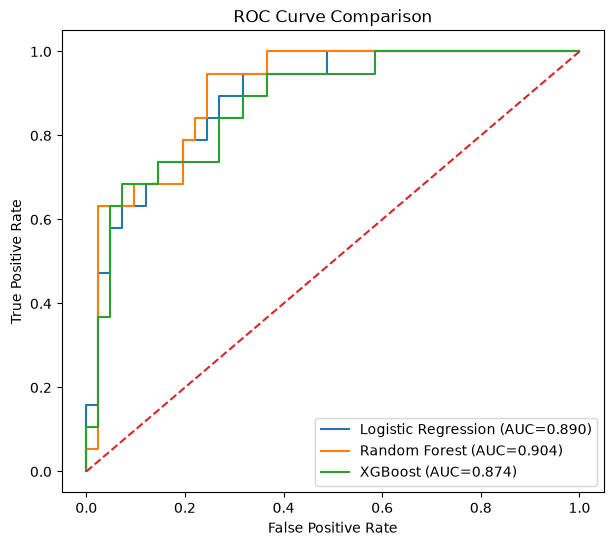

In [102]:
#三个模型ROC曲线对比
from sklearn.metrics import roc_curve

plt.figure(figsize=(7,6))

models = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "XGBoost": y_prob
}


for name, prob in models.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    auc_value = roc_auc_score(
        y_test,
        prob
    )


    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve Comparison"
)


plt.legend()


plt.show()